<a href="https://colab.research.google.com/github/PhilippStahlbergGit/DAT255_project_deep_learning/blob/main/DAT255_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First section

Some tasks to do:

*  Heat map & do more investigation https://deeplearningwithpython.io/chapters/chapter10_interpreting-what-convnets-learn/
*  Adjust CNN currently made __(Philipp, ongoing)__
* Do even more investigation to showcase that there might be something wrong with it
* Adjust so that we either have tumor or notumor, (so therefor all of the tumor ones should just be adjusted to be TUMOR, and be mixed with eathother, perhaps...?)
* Adjust images on model
* Use a pretained model (ResNet, Yolo)
* Change from classification to object detection and use the other dataset to use this
* Try this out on our dataset 2



## Setting things up
With env. variables below.

In [ ]:
!pip -q install kagglehub

In [ ]:
import os
from google.colab import userdata
import kagglehub
from pathlib import Path

# go into env variables in colab, set KAGGLE_API_TOKEN = [TOKEN]
# retrive this token from kaggle (in settings, make a new API key)
token = userdata.get("KAGGLE_API_TOKEN")
if not token:
    raise ValueError("Missing Colab Secret: KAGGLE_API_TOKEN")

os.environ["KAGGLE_API_TOKEN"] = token

root = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
print("Dataset root:", root)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset root: /kaggle/input/brain-tumor-mri-dataset


## Data retrival

Use this data first: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
and to confirm later:
https://docs.ultralytics.com/datasets/detect/brain-tumor/


In [ ]:
train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_path = "/kaggle/input/brain-tumor-mri-dataset/Testing"

classes = os.listdir(train_path)
print('Different classes: ', classes)

Different classes:  ['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
import pandas as pd
data_info = []
for cls in classes:
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    data_info.append([cls, train_count, test_count])

df = pd.DataFrame(data_info, columns=["Class", "Train Count", "Test Count"])
print(df)


        Class  Train Count  Test Count
0   pituitary         1400         400
1     notumor         1400         400
2  meningioma         1400         400
3      glioma         1400         400


Let us investigate how the images look like for the different classes, and see if there is anything that is of note.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random

IMG_EXTS = {".jpg"} # we only have jpg images for this proj.
imgs = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]

In [ ]:
cls_imgs_glioma = []
cls_imgs_meningioma = []
cls_imgs_pituitary = []
cls_imgs_no_tumor = []

# for later checking a specific class image
for cls in classes:
    if cls == "glioma":
      cls_imgs_glioma = [p for p in imgs if p.parent.name == cls]
    if cls == "meningioma":
      cls_imgs_meningioma = [p for p in imgs if p.parent.name == cls]
    if cls == "pituitary":
      cls_imgs_pituitary = [p for p in imgs if p.parent.name == cls]
    if cls == "notumor":
      cls_imgs_no_tumor = [p for p in imgs if p.parent.name == cls]


In [ ]:
glioma_samples = random.sample(cls_imgs_glioma, k=min(3, len(cls_imgs_glioma)))
meningioma_samples = random.sample(cls_imgs_meningioma, k=min(3, len(cls_imgs_meningioma)))
pituitary_samples = random.sample(cls_imgs_pituitary, k=min(3, len(cls_imgs_pituitary)))
notumor_samples = random.sample(cls_imgs_no_tumor, k=min(3, len(cls_imgs_no_tumor)))

Run this block below a couple of times, and try to see if there is some feature within classes, that make the images (perhaps) distinct technically, without necessarly being medically distinct:

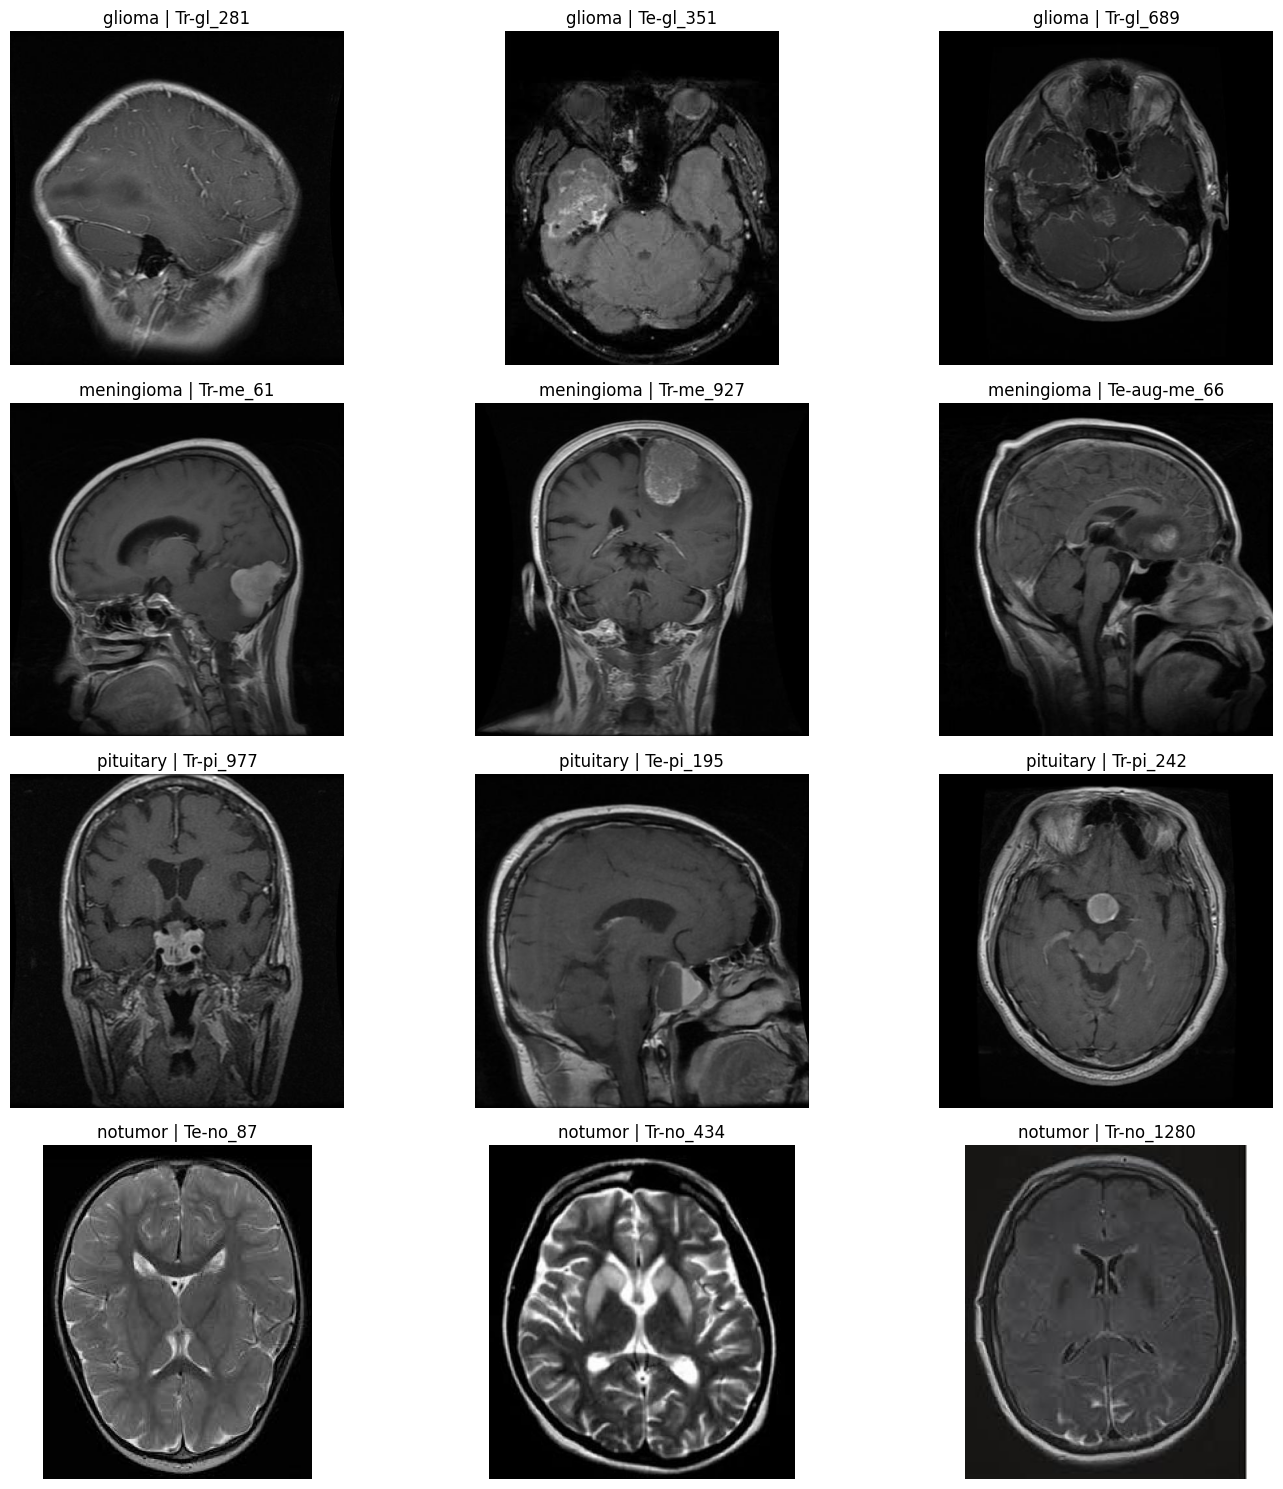

In [ ]:
all_samples = glioma_samples + meningioma_samples + pituitary_samples + notumor_samples

fig, axes = plt.subplots(len(classes), 3, figsize=(15, 15))
axes = axes.flatten()

for i, p in enumerate(all_samples):
    img = Image.open(p).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"{p.parent.name} | {p.name.split('.')[0]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

If you run the previous script, a couple of times, one might notice that at the very least, the notumor class seems to have images that are distinct in how they are presented, i.e a high contrast of some sort, let us investigate more deeply:

In [ ]:
sample_contrast_notumor = cls_imgs_no_tumor[1:5]

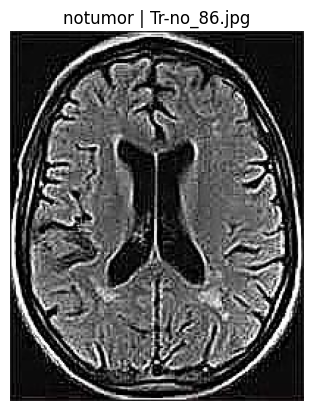

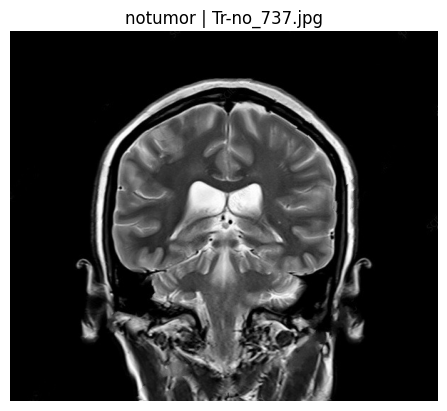

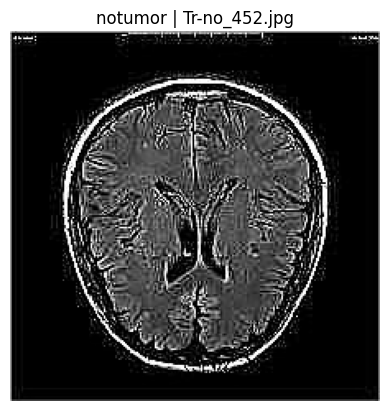

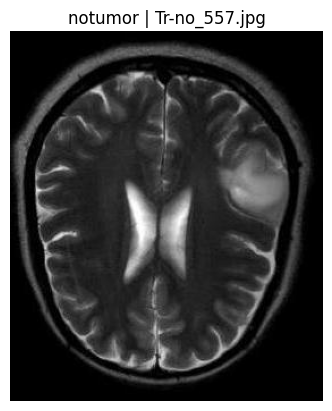

In [ ]:
for p in sample_contrast_notumor:
    img = Image.open(p).convert("RGB")
    plt.figure()
    plt.title(f"{p.parent.name} | {p.name}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

This might also not just be for notumor, but for the other classes also, there has been discussions about it in the `kaggle forum` from where we have retrived the data from, although some duplications have been removed, some of these biases might still be present, but let us look at the image resolution before we continue:

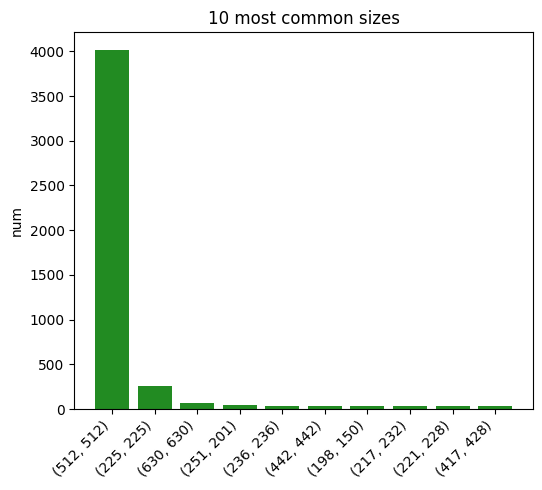

In [ ]:
import cv2
from collections import Counter

all_sizes = []

for cls in classes:
    cls_path = os.path.join(train_path, cls)
    img_files = os.listdir(cls_path)

    for img_file in img_files:
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path)

        all_sizes.append(img.shape[:2])

size_counter = Counter(all_sizes)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
top_sizes = dict(sorted(size_counter.items(), key=lambda x: x[1], reverse=True)[:10])
plt.bar([str(k) for k in top_sizes.keys()], top_sizes.values(), color='forestgreen')
plt.title('10 most common sizes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('num')


plt.tight_layout()
plt.show()

It looks like we mostly have `512 x 512` as our image dimentions, either we can trasnform all of them into some `closer to common grounds-dimention` or we can use say only `(51

## Introduction


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random

In [ ]:


X = []
y = []

for cls in classes:
    cls_path = os.path.join(train_path, cls)

    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (256, 256))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=-1)

        X.append(img)
        y.append(cls)

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y = y_encoded.astype(np.float32)



In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report


Model built by inpiration from: https://www.kaggle.com/code/zaahaa/tumor-detection-with-cnn-95-accuracy
Where we use the same reasoning to also predict on the image.

In [ ]:
model = models.Sequential()

# block 1
model.add(layers.Conv2D(32, (3,3), activation="relu", input_shape=(256, 256, 1)))
model.add(layers.MaxPooling2D((2,2)))

# block 2
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# block 3
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# classifier
model.add(layers.Flatten())
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(4, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,916 (56.61 MB)

 Trainable params: 14,838,916 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)



In [ ]:


# train the model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)



Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - accuracy: 0.5872 - loss: 1.0082 - val_accuracy: 0.7988 - val_loss: 0.5230
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8319 - loss: 0.4560 - val_accuracy: 0.8690 - val_loss: 0.3198
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8700 - loss: 0.3312 - val_accuracy: 0.8905 - val_loss: 0.2658
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9101 - loss: 0.2407 - val_accuracy: 0.9000 - val_loss: 0.2552
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9384 - loss: 0.1765 - val_accuracy: 0.9179 - val_loss: 0.2171
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9545 - loss: 0.1146 - val_accuracy: 0.9190 - val_loss: 0.2101
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9696 - loss: 0.0837 - val_accuracy: 0.9321 - val_loss: 0.2155
Epoch 8/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9692 - loss: 0.0770 -

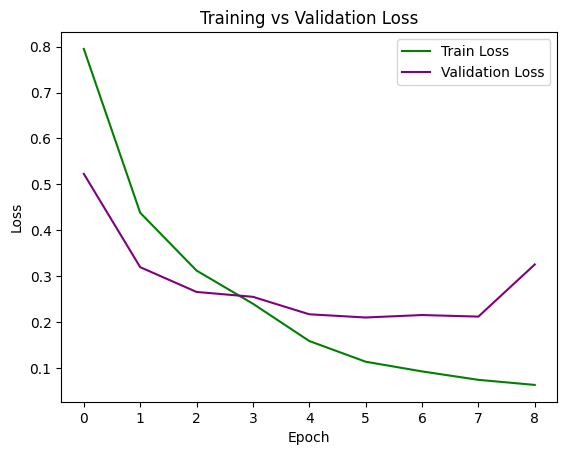

In [ ]:
plt.figure()
plt.plot(history.history['loss'], color='green', label='Train Loss')
plt.plot(history.history['val_loss'], color='purple', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
# testing the test data
X_test = []
y_test = []

test_classes = os.listdir(test_path)

for cls in test_classes:
    cls_path = os.path.join(test_path, cls)

    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (256, 256))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=-1)

        X_test.append(img)
        y_test.append(cls)

X_test = np.array(X_test)
y_test = np.array(y_test)

le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_test = y_test_encoded.astype(np.float32)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy: ', test_acc)



50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9299 - loss: 0.2775
Test Accuracy:  0.8693749904632568
